# S7C-C: causal retarded-bearing manoeuvre comparison

Paired direct-bearing sequences compare unchanged `confirmed_recovery` with explicitly enabled stochastic augmented history. Truth is evaluator-only. No acoustic frontend, smoothing, wind or reflections. Statistical units are independent sequences, **not** dependent time publications. Protocol: [`S7C_MANOEUVRE_PROTOCOL.md`](../S7C_MANOEUVRE_PROTOCOL.md).

In [1]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
root = Path.cwd()
if not (root / 'results' / 'manoeuvre_tracking_summary.csv').exists():
    root = root.parent
results = root / 'results'
def load(name):
    with (results / name).open(encoding='utf-8', newline='') as stream:
        return list(csv.DictReader(stream))
summary = load('manoeuvre_tracking_summary.csv')
frames = load('manoeuvre_tracking_frames.csv')
sequences = load('manoeuvre_tracking_sequences.csv')
development = load('manoeuvre_development_selection.csv')
paired_ci = load('manoeuvre_paired_ci.csv')
assert all(int(row['independent_sequence_count']) == 8 for row in summary)
assert {int(row['seed']) for row in frames} == {20260916}
assert {int(row['development_seed']) for row in development} == {20260915}
print('Frozen development candidates:', [(r['alpha_m2_s3'], r['development_selection_score_m'], r['during_valid_fraction']) for r in development])

Frozen development candidates: [('0.05', '10.759508329986911', '0.9583333333333334'), ('0.25', '2.6270881253145344', '1.0'), ('1.0', '2.1224117174425072', '1.0')]


`F(h)=[[I,hI],[0,I]]`, `Qd(h)=[[h³Qc/3,h²Qc/2],[h²Qc/2,hQc]]`. The filter's white-acceleration uncertainty is **not** the deterministic prescribed truth acceleration. Retarded emission uses available history, while transport availability only controls when an event can be consumed. CI resampling uses whole sequence pairs. Coverage is empirical, not CRLB.

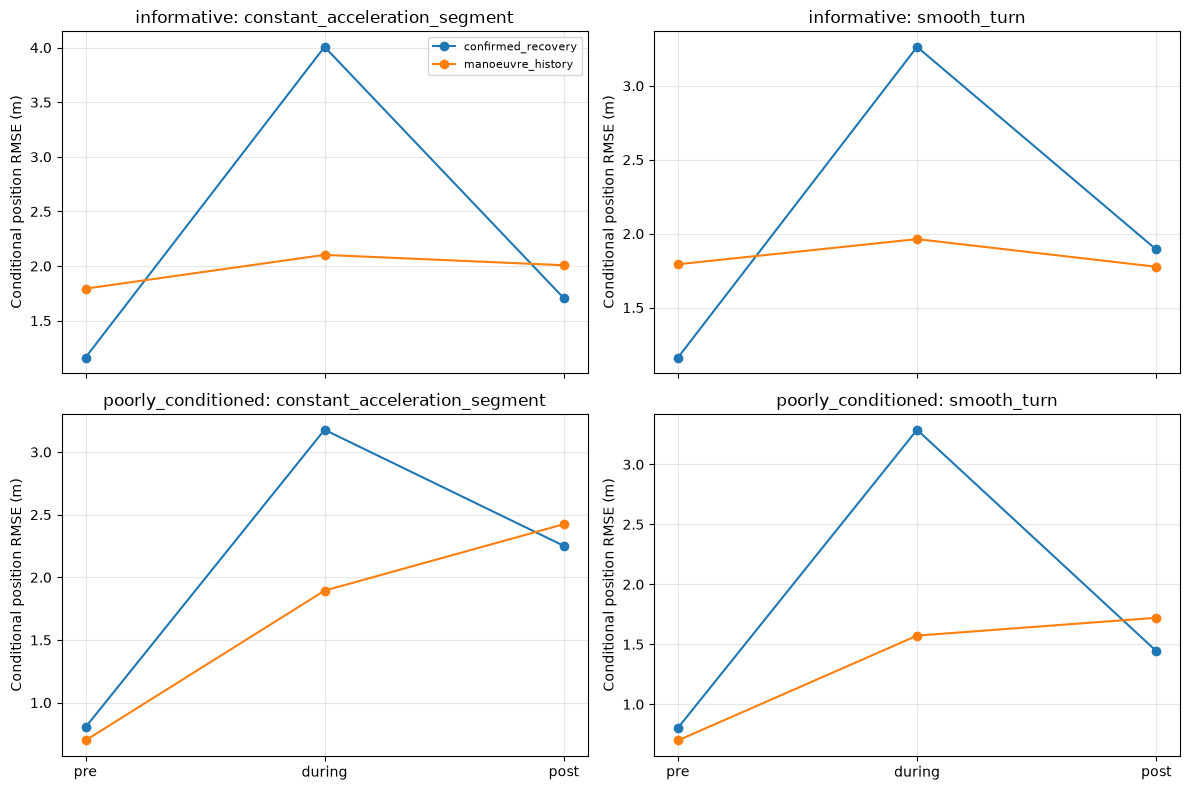

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
periods = ['pre', 'during', 'post']
for row, geometry in enumerate(['informative', 'poorly_conditioned']):
    for col, kind in enumerate(['constant_acceleration_segment', 'smooth_turn']):
        ax = axes[row, col]
        for variant in ['confirmed_recovery', 'manoeuvre_history']:
            part = {r['period']: r for r in summary if r['geometry'] == geometry and r['trajectory_kind'] == kind and r['variant'] == variant}
            ax.plot(periods, [float(part[p]['position_rmse_m_conditional']) for p in periods], marker='o', label=variant)
        ax.set_title(f'{geometry}: {kind}')
        ax.set_ylabel('Conditional position RMSE (m)')
        ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8)
fig.tight_layout(); plt.show()

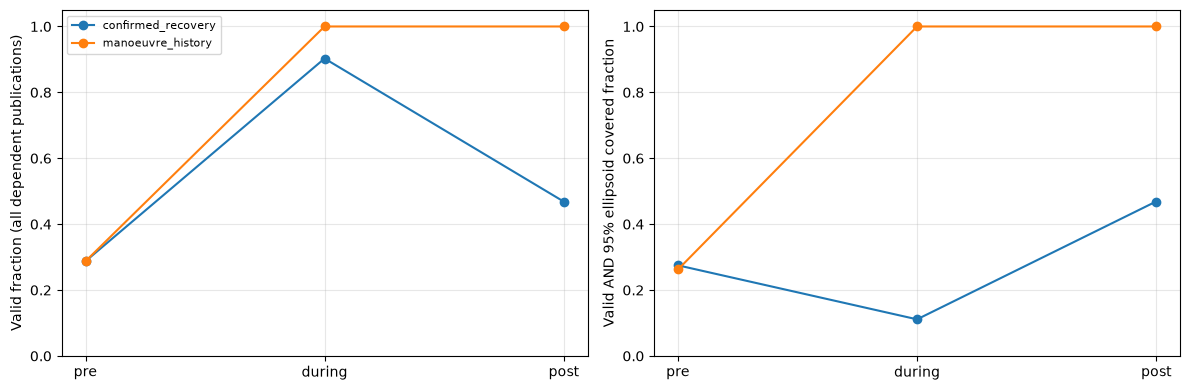

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for variant in ['confirmed_recovery', 'manoeuvre_history']:
    part = {r['period']: r for r in summary if r['geometry'] == 'informative' and r['trajectory_kind'] == 'smooth_turn' and r['variant'] == variant}
    axes[0].plot(periods, [float(part[p]['valid_fraction']) for p in periods], marker='o', label=variant)
    axes[1].plot(periods, [float(part[p]['valid_and_covered_fraction']) for p in periods], marker='o', label=variant)
axes[0].set_ylabel('Valid fraction (all dependent publications)')
axes[1].set_ylabel('Valid AND 95% ellipsoid covered fraction')
for ax in axes: ax.set_ylim(0, 1.05); ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

In [4]:
for row in paired_ci:
    if row['period'] == 'during':
        print(row['geometry'], row['trajectory_kind'], 'matched', row['matched_valid_publication_count'], 'paired ΔRMSE', row['manoeuvre_minus_recovery_position_rmse_m'], 'CI', row['paired_bootstrap_ci_low_m'], row['paired_bootstrap_ci_high_m'])
for row in summary:
    if row['period'] == 'during' and row['trajectory_kind'] != 'constant_velocity':
        print(row['geometry'], row['trajectory_kind'], row['variant'], 'valid', row['valid_fraction'], 'RMSE', row['position_rmse_m_conditional'], 'coverage', row['coverage_conditional'])

informative constant_velocity matched 72 paired ΔRMSE 0.8013024000944372 CI 0.5304932144962302 1.1329769788415434
informative constant_acceleration_segment matched 64 paired ΔRMSE -1.9382552603012093 CI -2.3000119327951194 -1.5471123026392846
informative smooth_turn matched 65 paired ΔRMSE -1.3133010564576593 CI -1.626943854351754 -0.9071950917337318
poorly_conditioned constant_velocity matched 70 paired ΔRMSE 0.6025248836951445 CI 0.39507477679170155 0.784353920644891
poorly_conditioned constant_acceleration_segment matched 51 paired ΔRMSE -1.4684547295710915 CI -2.0222228623825282 -0.9321210409739017
poorly_conditioned smooth_turn matched 60 paired ΔRMSE -1.8269250944488338 CI -2.3909981996403578 -1.0370192743587714
informative constant_acceleration_segment confirmed_recovery valid 0.8888888888888888 RMSE 4.007278443865638 coverage 0.125
informative constant_acceleration_segment manoeuvre_history valid 1.0 RMSE 2.102568368231387 coverage 1.0
informative smooth_turn confirmed_recovery

The comparison is a limited synthetic bearing-level benchmark. Conditional error must be read with availability; invalid outputs are not silently scored as successes. Histories retain the full joint covariance and update delayed observations causally. This does **not** validate field manoeuvre tracking, real audio, correlated observation errors, environmental acoustics, or calibration of stochastic covariance. Starting directly during manoeuvre was not tested.